In [1]:
# ============================================================
# Diabetes Tool - Exploratory Data Analysis
# Dataset 1: PIMA Indians Diabetes Database
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load PIMA dataset
pima = pd.read_csv('../data/raw/pima/diabetes.csv')

# Basic info
print("Shape:", pima.shape)
print("\nColumns:", pima.columns.tolist())
print("\nFirst 5 rows:")
pima.head()

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Basic statistics
print("Data Types:")
print(pima.dtypes)
print("\nMissing Values:")
print(pima.isnull().sum())
print("\nClass Distribution:")
print(pima['Outcome'].value_counts())
print(f"\nDiabetes Rate: {pima['Outcome'].mean()*100:.1f}%")
print("\nStatistical Summary:")
pima.describe()

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes Rate: 34.9%

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Zero counts in biologically impossible columns:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)


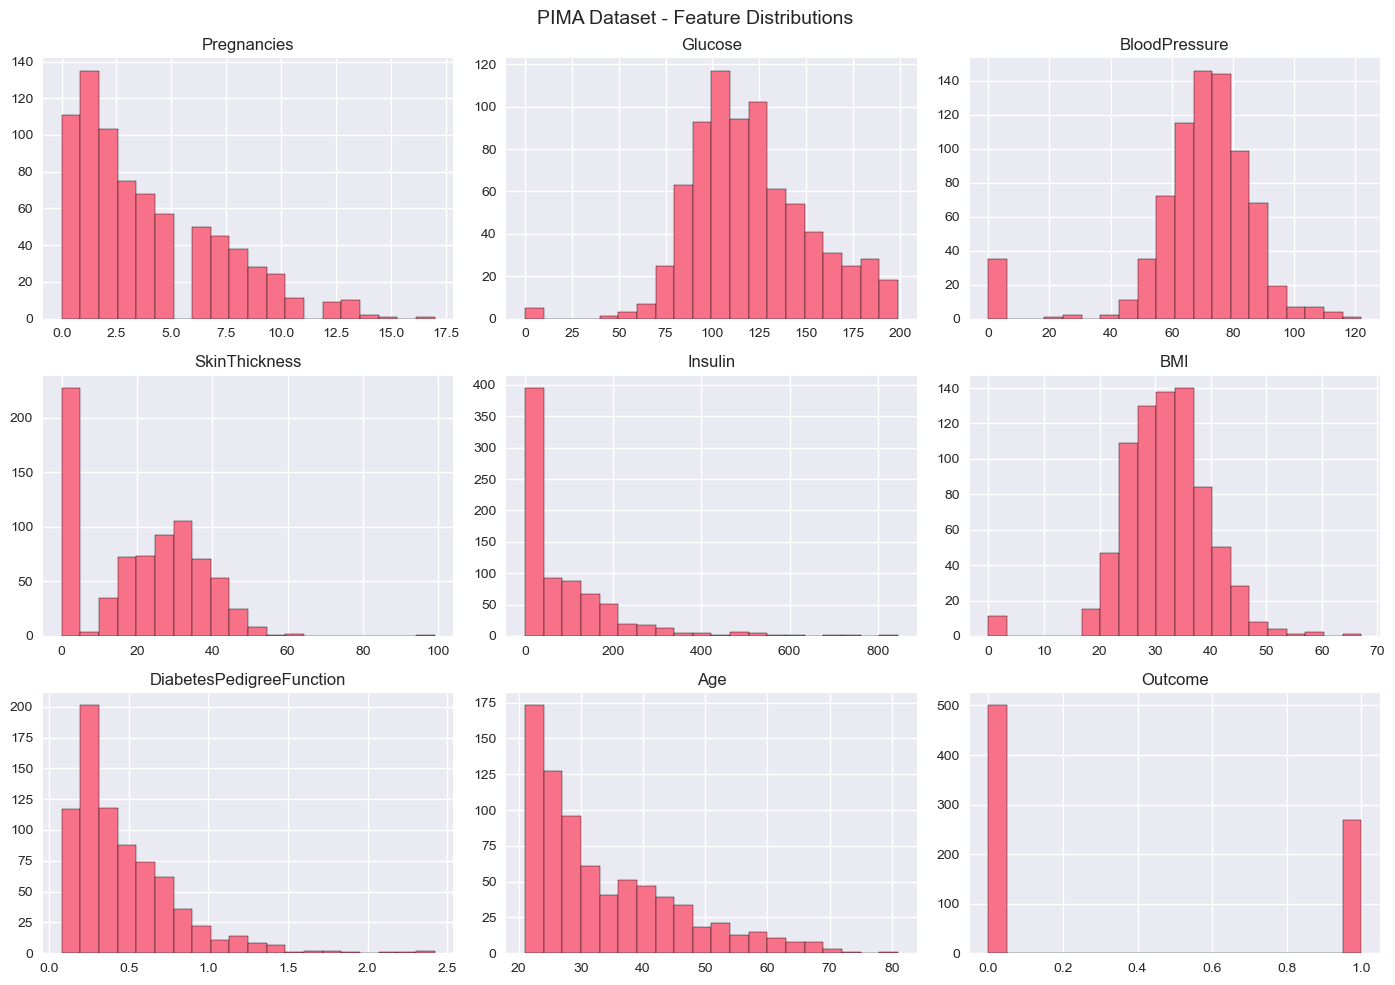

Plot saved


In [4]:
# Visualize zero values that are actually missing data
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts in biologically impossible columns:")
for col in zero_cols:
    zeros = (pima[col] == 0).sum()
    pct = zeros/len(pima)*100
    print(f"  {col}: {zeros} zeros ({pct:.1f}%)")

# Visualize distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('PIMA Dataset - Feature Distributions', fontsize=14)

for idx, col in enumerate(pima.columns):
    ax = axes[idx//3][idx%3]
    pima[col].hist(ax=ax, bins=20, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../data/processed/pima_distributions.png', dpi=150)
plt.show()
print("Plot saved")

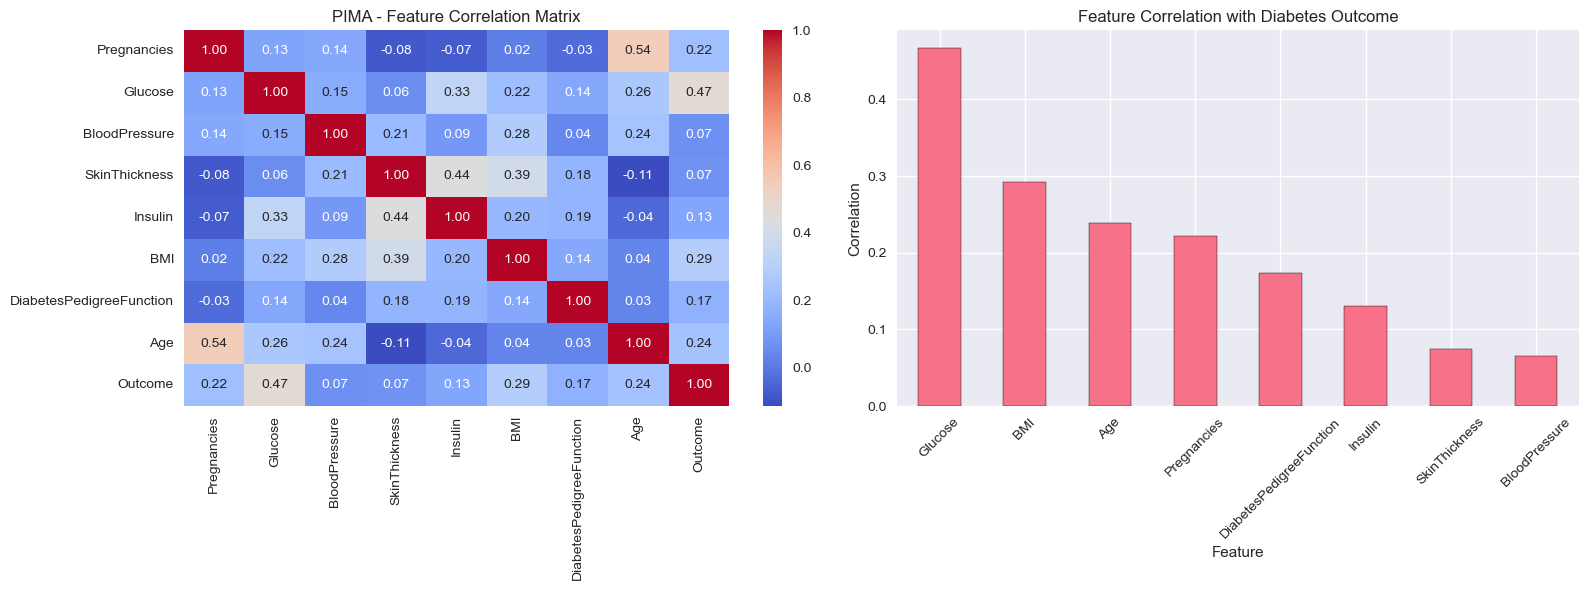

Plot saved


In [5]:
# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall correlation
sns.heatmap(pima.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', ax=axes[0])
axes[0].set_title('PIMA - Feature Correlation Matrix')

# Correlation with outcome specifically
outcome_corr = pima.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
outcome_corr.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Feature Correlation with Diabetes Outcome')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Correlation')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/pima_correlations.png', dpi=150)
plt.show()
print("Plot saved")

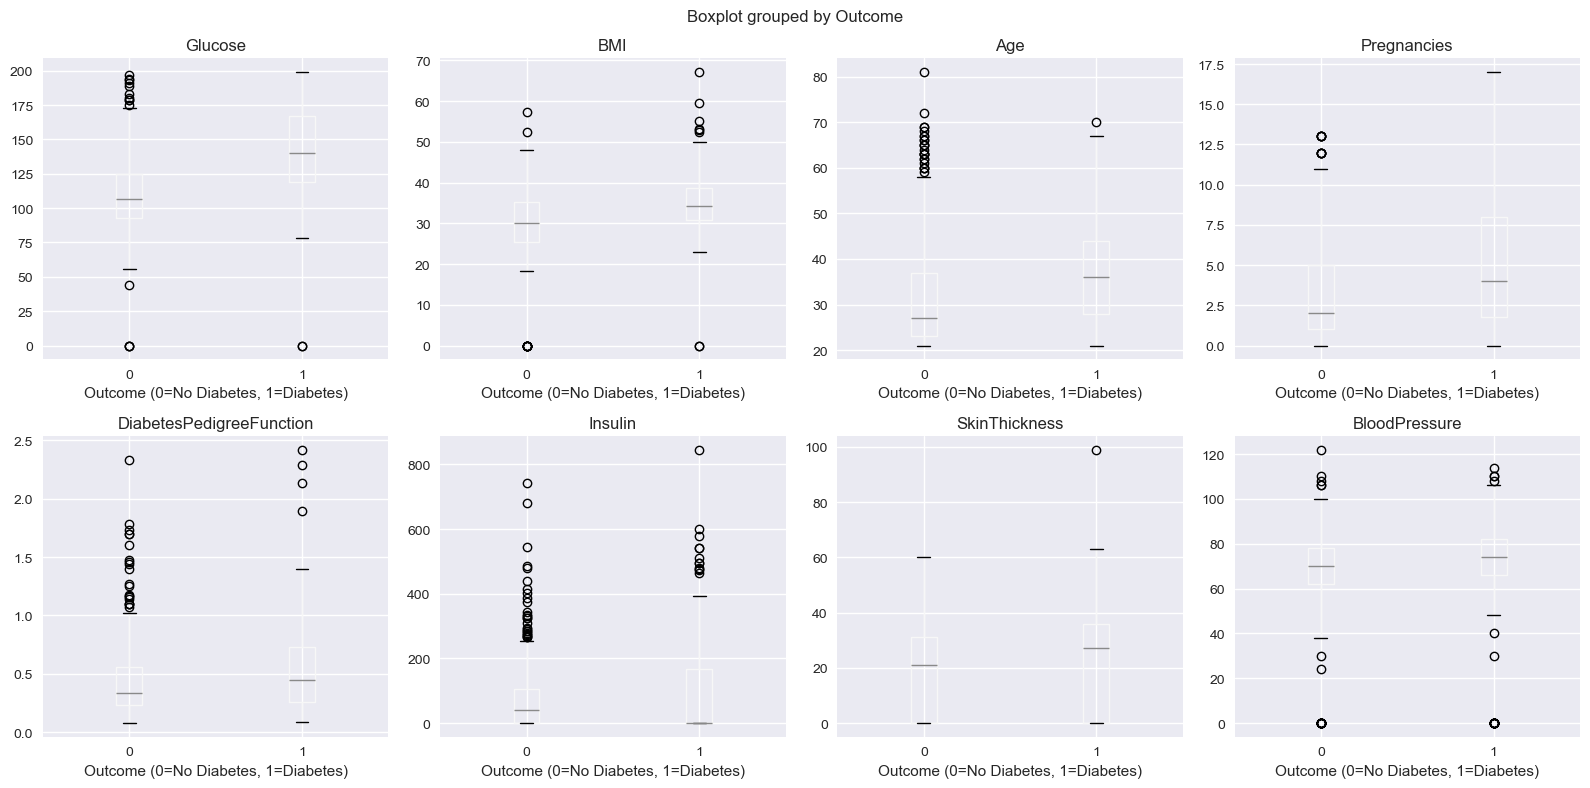

PIMA EDA complete


In [6]:
# Feature distributions by diabetes outcome
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('PIMA - Feature Distributions by Diabetes Outcome', fontsize=14)

features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 
            'DiabetesPedigreeFunction', 'Insulin', 
            'SkinThickness', 'BloodPressure']

for idx, col in enumerate(features):
    ax = axes[idx//4][idx%4]
    pima.boxplot(column=col, by='Outcome', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Outcome (0=No Diabetes, 1=Diabetes)')

plt.tight_layout()
plt.savefig('../data/processed/pima_boxplots.png', dpi=150)
plt.show()
print("PIMA EDA complete")

In [7]:
# ============================================================
# Dataset 2: CDC BRFSS Diabetes Health Indicators
# ============================================================

brfss = pd.read_csv('../data/raw/brfss/diabetes_binary_health_indicators_BRFSS2015.csv')

print("Shape:", brfss.shape)
print("\nColumns:", brfss.columns.tolist())
print("\nClass Distribution:")
print(brfss['Diabetes_binary'].value_counts())
print(f"\nDiabetes Rate: {brfss['Diabetes_binary'].mean()*100:.1f}%")
print("\nMissing Values:")
print(brfss.isnull().sum().sum(), "total missing values")
print("\nStatistical Summary:")
brfss.describe()

Shape: (253680, 22)

Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Class Distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Diabetes Rate: 13.9%

Missing Values:
0 total missing values

Statistical Summary:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


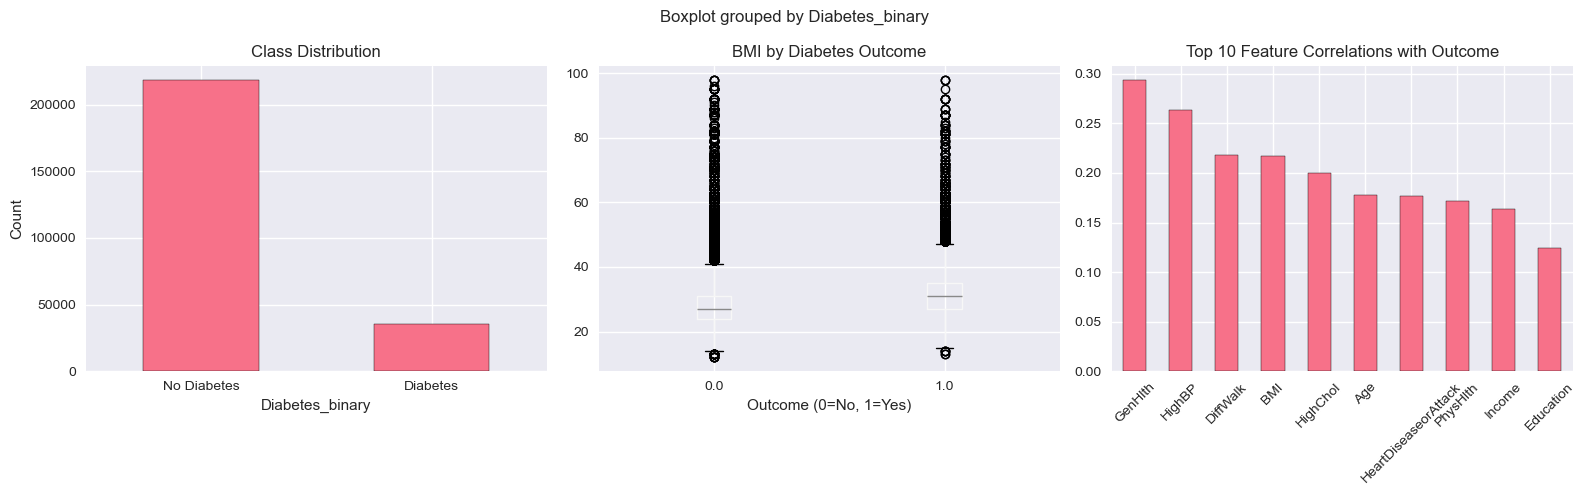

BRFSS EDA complete


In [8]:
# BRFSS - Class imbalance and key feature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BRFSS - Key Distributions', fontsize=14)

# Class distribution
brfss['Diabetes_binary'].value_counts().plot(
    kind='bar', ax=axes[0], edgecolor='black'
)
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
axes[0].set_ylabel('Count')

# BMI distribution by outcome
brfss.boxplot(column='BMI', by='Diabetes_binary', ax=axes[1])
axes[1].set_title('BMI by Diabetes Outcome')
axes[1].set_xlabel('Outcome (0=No, 1=Yes)')

# Top feature correlations with outcome
outcome_corr = brfss.corr()['Diabetes_binary'].drop('Diabetes_binary')
outcome_corr.abs().sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[2], edgecolor='black'
)
axes[2].set_title('Top 10 Feature Correlations with Outcome')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/brfss_distributions.png', dpi=150)
plt.show()
print("BRFSS EDA complete")

In [9]:
# ============================================================
# Dataset 3: Sylhet Diabetes Dataset (South Asian)
# ============================================================

sylhet = pd.read_csv('../data/raw/sylhet/diabetes_data_upload.csv')

print("Shape:", sylhet.shape)
print("\nColumns:", sylhet.columns.tolist())
print("\nClass Distribution:")
print(sylhet['class'].value_counts())
print(f"\nDiabetes Rate: {(sylhet['class']=='Positive').mean()*100:.1f}%")
print("\nMissing Values:")
print(sylhet.isnull().sum().sum(), "total missing values")
print("\nData Sample:")
sylhet.head()

Shape: (520, 17)

Columns: ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class']

Class Distribution:
class
Positive    320
Negative    200
Name: count, dtype: int64

Diabetes Rate: 61.5%

Missing Values:
0 total missing values

Data Sample:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


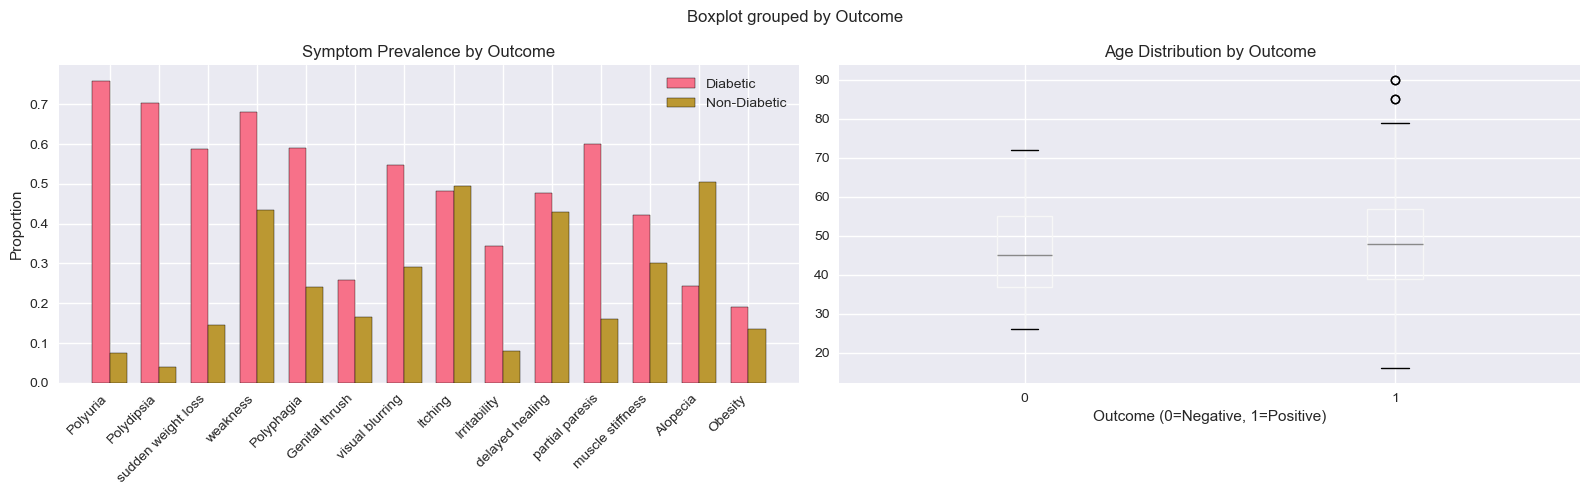

Sylhet EDA complete


In [11]:
# Sylhet - Feature distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Sylhet Dataset - South Asian Diabetes Symptoms', fontsize=14)

# Symptom prevalence by outcome
symptom_cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
                'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
                'Irritability', 'delayed healing', 'partial paresis',
                'muscle stiffness', 'Alopecia', 'Obesity']

# Convert Yes/No to 1/0
sylhet_binary = sylhet.copy()
for col in symptom_cols:
    sylhet_binary[col] = (sylhet_binary[col] == 'Yes').astype(int)
sylhet_binary['Gender'] = (sylhet_binary['Gender'] == 'Male').astype(int)
sylhet_binary['Outcome'] = (sylhet_binary['class'] == 'Positive').astype(int)

# Symptom prevalence in diabetic vs non diabetic
positive = sylhet_binary[sylhet_binary['Outcome']==1][symptom_cols].mean()
negative = sylhet_binary[sylhet_binary['Outcome']==0][symptom_cols].mean()

x = range(len(symptom_cols))
width = 0.35
axes[0].bar([i - width/2 for i in x], positive, width, 
            label='Diabetic', edgecolor='black')
axes[0].bar([i + width/2 for i in x], negative, width,
            label='Non-Diabetic', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(symptom_cols, rotation=45, ha='right')
axes[0].set_title('Symptom Prevalence by Outcome')
axes[0].set_ylabel('Proportion')
axes[0].legend()

# Age distribution by outcome
sylhet_binary.boxplot(column='Age', by='Outcome', ax=axes[1])
axes[1].set_title('Age Distribution by Outcome')
axes[1].set_xlabel('Outcome (0=Negative, 1=Positive)')

plt.tight_layout()
plt.savefig('../data/processed/sylhet_distributions.png', dpi=150)
plt.show()
print("Sylhet EDA complete")

In [12]:
# ============================================================
# Dataset 4: 130-US Hospitals Diabetes Dataset
# ============================================================

hospitals = pd.read_csv('../data/raw/hospitals/diabetic_data.csv')

print("Shape:", hospitals.shape)
print("\nColumns:", hospitals.columns.tolist())
print("\nFirst 5 rows:")
hospitals.head()

Shape: (101766, 50)

Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [13]:
# Hospital dataset - missing value analysis
import numpy as np

# Replace ? with NaN
hospitals_clean = hospitals.replace('?', np.nan)

print("Missing Values (top 15):")
missing = hospitals_clean.isnull().sum()
missing_pct = (missing/len(hospitals_clean)*100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0].head(15))

print("\nReadmission Distribution:")
print(hospitals['readmitted'].value_counts())

print("\nAge Distribution:")
print(hospitals['age'].value_counts().sort_index())

print("\nRace Distribution:")
print(hospitals_clean['race'].value_counts())

Missing Values (top 15):
                   Missing Count  Missing %
weight                     98569       96.9
max_glu_serum              96420       94.7
A1Cresult                  84748       83.3
medical_specialty          49949       49.1
payer_code                 40256       39.6
race                        2273        2.2
diag_3                      1423        1.4
diag_2                       358        0.4
diag_1                        21        0.0

Readmission Distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Age Distribution:
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

Race Distribution:
race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


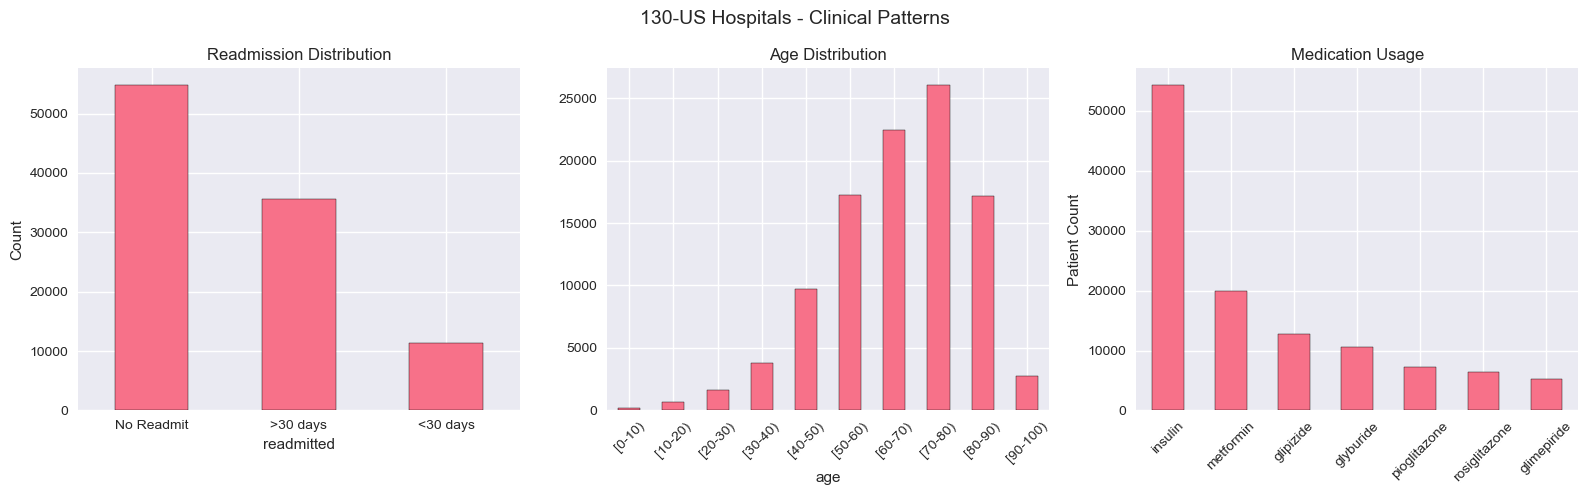

Hospital EDA complete


In [14]:
# Hospital dataset - medication and readmission analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('130-US Hospitals - Clinical Patterns', fontsize=14)

hospitals_clean = hospitals.replace('?', np.nan)

# Readmission distribution
hospitals['readmitted'].value_counts().plot(
    kind='bar', ax=axes[0], edgecolor='black'
)
axes[0].set_title('Readmission Distribution')
axes[0].set_xticklabels(['No Readmit', '>30 days', '<30 days'], rotation=0)
axes[0].set_ylabel('Count')

# Age distribution
hospitals['age'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], edgecolor='black'
)
axes[1].set_title('Age Distribution')
axes[1].tick_params(axis='x', rotation=45)

# Top medications usage
med_cols = ['metformin', 'insulin', 'glipizide', 'glyburide', 
            'pioglitazone', 'rosiglitazone', 'glimepiride']
med_usage = {}
for med in med_cols:
    med_usage[med] = (hospitals[med] != 'No').sum()

pd.Series(med_usage).sort_values(ascending=False).plot(
    kind='bar', ax=axes[2], edgecolor='black'
)
axes[2].set_title('Medication Usage')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('Patient Count')

plt.tight_layout()
plt.savefig('../data/processed/hospitals_distributions.png', dpi=150)
plt.show()
print("Hospital EDA complete")

In [15]:
# ============================================================
# EDA Summary - Dataset Comparison
# ============================================================

summary = pd.DataFrame({
    'Dataset': ['PIMA Indians', 'BRFSS', 'Sylhet', '130-US Hospitals'],
    'Rows': [len(pima), len(brfss), len(sylhet), len(hospitals)],
    'Features': [9, 22, 17, 50],
    'Diabetes Rate %': [34.9, 13.9, 61.5, 100.0],
    'Missing Values': ['Disguised as 0s', 'None', 'None', '? encoding'],
    'Population': ['Pima Native American Women', 'US General Population', 
                   'South Asian (Bangladesh)', 'US Inpatient Diabetics'],
    'Use in Project': ['Risk scoring', 'Risk scoring', 
                       'Risk scoring', 'Medication analysis']
})

print("=" * 60)
print("DATASET COMPARISON SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
print("\nTotal rows across all datasets:", 
      len(pima) + len(brfss) + len(sylhet) + len(hospitals))
print("Rows for risk scoring model:", 
      len(pima) + len(brfss) + len(sylhet))
print("\nKey challenges for harmonization:")
print("  1. Different feature schemas across datasets")
print("  2. Disguised missing values in PIMA (zeros)")
print("  3. Categorical age brackets in BRFSS and Hospitals")
print("  4. Yes/No encoding in Sylhet vs numeric in PIMA/BRFSS")
print("  5. Severe class imbalance in BRFSS (13.9% positive)")
print("  6. Sylhet is symptom-based, others are lab/survey-based")

DATASET COMPARISON SUMMARY
         Dataset   Rows  Features  Diabetes Rate %  Missing Values                 Population      Use in Project
    PIMA Indians    768         9             34.9 Disguised as 0s Pima Native American Women        Risk scoring
           BRFSS 253680        22             13.9            None      US General Population        Risk scoring
          Sylhet    520        17             61.5            None   South Asian (Bangladesh)        Risk scoring
130-US Hospitals 101766        50            100.0      ? encoding     US Inpatient Diabetics Medication analysis

Total rows across all datasets: 356734
Rows for risk scoring model: 254968

Key challenges for harmonization:
  1. Different feature schemas across datasets
  2. Disguised missing values in PIMA (zeros)
  3. Categorical age brackets in BRFSS and Hospitals
  4. Yes/No encoding in Sylhet vs numeric in PIMA/BRFSS
  5. Severe class imbalance in BRFSS (13.9% positive)
  6. Sylhet is symptom-based, others